# add_damage_record.ipynb
Add a new damages record to the database.

In [1]:
%matplotlib widget
import ipympl
import matplotlib.pyplot as plt
import sqlite3
from icecream import ic 
import numpy as np
import shapely
from shapely import wkt
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour
import cv2
from shapely.geometry import Polygon
from shapely.wkt import dumps
import re
from contextlib import contextmanager

In [2]:
db_path = 'new.db'
image_id = 1
tree_id = 1
order = 15

In [3]:
@contextmanager
def open_db(db_path=db_path):
    conn = sqlite3.connect(db_path)
    try:
        # 1. Configure Row Factory (built-in dictionary-like rows)
        conn.row_factory = sqlite3.Row
        
        # 2. Load SpatiaLite Extension
        conn.enable_load_extension(True)
        conn.load_extension("mod_spatialite") 
        
        # Yield the fully configured connection
        yield conn
        
        conn.commit()
    except Exception:
        conn.rollback()
        raise
    finally:
        conn.close()

# Usage example:

db_path = 'new.db'
with open_db() as conn:
    cursor = conn.cursor()
    
    # You can now use SpatiaLite functions right away
    cursor.execute("SELECT image_id FROM images WHERE damage_flag = 0")
    
    # Because of sqlite3.Row, you can access columns by name!
    image_id_queue = [row['image_id'] for row in cursor.fetchall()]    
    
    # Connection is automatically committed and closed here.
    
ic(image_id_queue);       

ic| image_id_queue: [1, 2]


In [4]:
!jupyter notebook --version

7.5.6


In [5]:
# get WKTs for for trees in a selected image
with open_db() as conn:
    cursor = conn.cursor()
    cursor.execute(f'SELECT AsWKT(tree_poly) FROM trees WHERE image_id={image_id}')
    tree_wkts = cursor.fetchall()
    # ic(tree_wkts)
    ic(len(tree_wkts))

ic| len(tree_wkts): 2


In [6]:
# Get coordinates array for first tree
wkt_string = tree_wkts[0][0]  # Get the WKT string from the first row
ic(wkt_string)
# ic(wkt_string)
# 1. Load the WKT into a Shapely geometry object
polygon = wkt.loads(wkt_string)

# 2. Extract the exterior coordinates and convert to a NumPy array
coords_array = np.array(polygon.exterior.coords)
coords_array = np.abs(coords_array)  # Ensure all coordinates are positive

# ic(coords_array)
# ic(coords_array.shape);

ic| wkt_string: 'POLYGON((486 -677,486 -682,485 -683,485 -687,484 -688,484 -689,482 -691,481 -691,478 -694,478 -706,477 -707,477 -718,479 -720,479 -721,482 -724,482 -725,483 -725,486 -728,486 -729,489 -732,489 -733,490 -734,490 -735,491 -736,491 -740,490 -741,489 -741,488 -742,486 -742,485 -743,475 -743,474 -744,473 -744,474 -744,475 -745,476 -745,477 -746,478 -746,479 -747,483 -747,484 -748,486 -748,487 -749,490 -749,491 -750,493 -750,495 -752,495 -753,496 -754,496 -757,495 -758,495 -759,493 -761,493 -762,491 -764,490 -764,489 -765,489 -766,488 -767,487 -767,486 -768,486 -769,484 -771,484 -772,483 -773,483 -774,482 -775,482 -778,479 -781,478 -781,477 -782,476 -782,473 -785,473 -788,472 -789,472 -791,471 -792,471 -799,470 -800,470 -806,475 -811,476 -811,477 -812,478 -812,479 -813,480 -813,482 -815,483 -815,486 -818,486 -819,487 -820,487 -821,486 -822,485 -822,484 -821,477 -821,477 -822,479 -822,480 -823,482 -823,484 -825,485 -825,486 -826,487 -826,488 -827,490 -827,491 -828,493 -828,49

In [7]:
# get elliptic Fourier descriptors for first tree

original_contour = coords_array

num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
# ic(original_contour)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)
# ic(coeffs)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)
# ic(dc_coeffs)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)
# ic(reconstructed_contour)

ic| image_path: '/home/aubrey/Desktop/crbdd/resources/example_images/08hs-palms-03-zglw-superJumbo.webp'


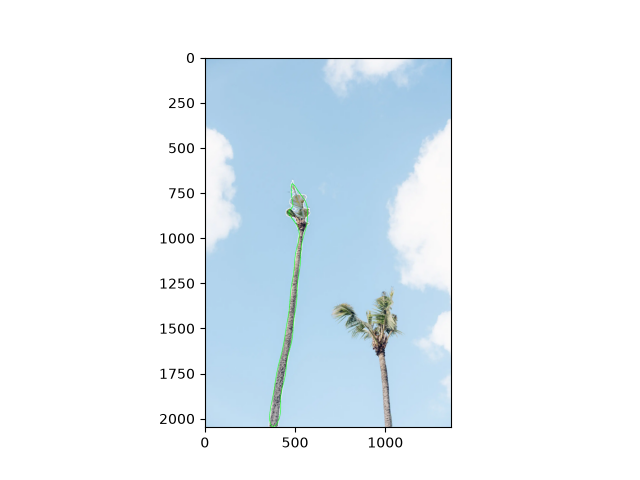

In [8]:
# display image with original contour and reconstructed contour for first tree

with open_db() as conn:
    cursor = conn.cursor()
    cursor.execute(f'SELECT image_path FROM images WHERE image_id = {image_id}')
    image_path = cursor.fetchone()['image_path']
    ic(image_path)
    
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# ic(img)

cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
# ic(img)

cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)

# 4. Initialize the figure and axes for the widget window
fig, ax = plt.subplots()

# 5. Render the image inside the interactive widget frame
ax.imshow(img)
plt.show()

In [9]:
def calc_damage_polygons(original_contour, reconstructed_contour):
    """  
    returns mask containing pixels which are in the reconstruction mask but not in the original mask
    """
    original_mask = np.zeros_like(img, dtype=np.uint8)
    cv2.fillPoly(original_mask, pts=[original_contour.astype(dtype=np.int32)], color=255)

    reconstructed_mask = np.zeros_like(img, dtype=np.uint8)
    cv2.fillPoly(reconstructed_mask, pts=[reconstructed_contour.astype(dtype=np.int32)], color=255)

    # Pixels missing in original, present in reconstruction
    diff_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(original_mask))

    # remove small blobs using connected components method
    #######################################################

    # Load your binary image (must be single-channel, uint8)
    binary_img = cv2.cvtColor(diff_mask, cv2.COLOR_BGR2GRAY)
    # ic(binary_img.shape)

    # 1. Find all connected components and their statistics
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_img, connectivity=8)

    # 2. Define your minimum area threshold (in pixels)
    min_area = 200 

    # 3. Create an empty mask to store large objects
    filtered_img = np.zeros_like(binary_img)

    # 4. Loop through components (skip index 0 as it represents the background)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if area >= min_area:
            # Keep components that meet the size constraint
            filtered_img[labels == i] = 255
            

    # Find connected components
    num_labels, labels_im = cv2.connectedComponents(filtered_img)

    # The background is counted as a label, so subtract 1 to get the blob count
    blob_count = num_labels - 1

    # ic(blob_count)
    ###########################################################################3        

    # ic(diff_mask)
    # ic(np.max(diff_mask))

    # gray_mask = cv2.cvtColor(diff_mask, cv2.COLOR_BGR2GRAY)
    damage_polygons, _ = cv2.findContours(
        image=filtered_img, 
        mode=cv2.RETR_EXTERNAL, 
        method=cv2.CHAIN_APPROX_NONE)
    return damage_polygons

# # Usage example:
# damage_polygons = calc_damage_polygons(original_contour, reconstructed_contour)
# ic(len(damage_polygons));
# ic(damage_polygons[0])


# fig, ax = plt.subplots()
# ax.imshow(filtered_img)
# plt.show()

In [10]:
def add_damage_polygons_to_db(damage_polygons):
    """  
    Add damage polygons to database
    """

    def wkt_to_ints(wkt_str):
        # Find all floating point or integer numbers in the WKT string
        return re.sub(r'-?\d+\.\d+', lambda m: str(round(float(m.group(0)))), wkt_str)

    damage_wkts = []
    for poly in damage_polygons:
        # poly = poly.astype(int) 
        poly = np.squeeze(poly)         # get rid of unnecessary dimensions
        if (poly[-1] != poly[0]).all(): # ensure polygon is closed
            np.vstack([poly, poly[0]])
        damage_wkt = dumps(Polygon(poly))
        damage_wkt = wkt_to_ints(damage_wkt)          # convert coords from float to int
        damage_wkts.append(damage_wkt)    

    with open_db() as conn:
        cursor = conn.cursor()
        for damage_wkt in damage_wkts:   # add records to damage table
            cursor.execute('INSERT INTO damage (image_id, tree_id, damage_poly) VALUES (?, ?, GeomFromText(?, 0))', 
                            (image_id, tree_id, damage_wkt))

In [11]:
# MAIN

# open database

# add damage_flag field to images table if it does not exist THIS BLOCK IS TEMPORARY
with open_db() as conn: 
    cursor = conn.cursor()
    try:
        # Attempt to add the column
        cursor.execute("ALTER TABLE images ADD COLUMN damage_flag INTEGER NOT NULL DEFAULT 0;")
        conn.commit()
        ic("damage_flag column added successfully!")
    except sqlite3.OperationalError as e:
        # If the error is because the column already exists, ignore it safely
        if "duplicate column name" in str(e):
            ic("damage_flag column already exists. Skipping.")
        else:
            # Re-raise if it's a completely different database error
            raise e

# clear all values from damage table; TEMP FOR TESTING
with open_db() as conn:
    cursor = conn.cursor()
    cursor.execute('DELETE from damage')
    ic('all values cleared from damage table for testing')
        
# get image_id_queue containing a list of image_ids for damage shape processing
with open_db() as conn: 
    cursor = conn.cursor()       
    cursor.execute("SELECT image_id FROM images WHERE damage_flag = 0")
    image_id_queue =[row['image_id'] for row in cursor.fetchall()]      

# get tree_id_queue containing a list of image_ids for damage shape processing
for image_id in image_id_queue:   
    with open_db() as conn:
        cursor = conn.cursor()
        cursor.execute(f'SELECT tree_id FROM trees WHERE image_id={image_id}')
        tree_id_queue = [row['tree_id'] for row in cursor.fetchall()]
        # ic(image_id, tree_id_queue)  

# process tree_queue        
for tree_id in tree_id_queue:
    
    # get WKT for tree polygon
    with open_db() as conn: 
        cursor = conn.cursor()       
        cursor.execute(f'SELECT AsText(tree_poly) AS tree_wkt FROM trees WHERE tree_id={tree_id}')
        tree_wkt = cursor.fetchone()['tree_wkt']
        # ic(tree_id, tree_wkt)
        
    # get coords
        
    # 1. Load the WKT into a Shapely geometry object
    polygon = wkt.loads(tree_wkt)

    # 2. Extract the exterior coordinates and convert to a NumPy array
    coords_array = np.array(polygon.exterior.coords)
    coords_array = np.abs(coords_array)  # Ensure all coordinates are positive
    
    # get elliptic Fourier descriptors

    original_contour = coords_array
    original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
    # ic(original_contour)

    # 1. Extract descriptors (keep normalize=False to retain native spatial details)
    coeffs = elliptic_fourier_descriptors(original_contour, order=order, normalize=False)
    # ic(coeffs)

    # 2. Extract DC spatial tracking offsets
    dc_coeffs = calculate_dc_coefficients(original_contour)
    # ic(dc_coeffs)

    # 3. Generate raw reconstruction (matching original row length for point parity)
    reconstructed_contour = reconstruct_contour(
        coeffs, 
        locus=dc_coeffs, 
        num_points=len(original_contour)
    )
    # ic(reconstructed_contour)
    
    damage_polygons = calc_damage_polygons(original_contour, reconstructed_contour)
    add_damage_polygons_to_db(damage_polygons)          

ic| 'damage_flag column already exists. Skipping.'
ic| 'all values cleared from damage table for testing'


In [12]:
ic('FINISHED')

ic| 'FINISHED'


'FINISHED'